In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import os
from sklearn.decomposition import PCA

from sklearn.metrics import f1_score

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

In [3]:
#Get data
PATHX = "DD//X_TR.csv"
PATHY = "DD//Y_TR.csv"

X = pd.read_csv(PATHX, sep = ",", index_col =0)
labels = pd.read_csv(PATHY, header=0, sep = "/n", index_col=False)

#Checking what labels we have
existing_labels = []
for i in labels["class"]:
    if i not in existing_labels:
        existing_labels.append(i)

print(existing_labels)

x = np.array(X)
labels = np.array(labels).ravel()
print(x.shape)

#scaler = StandardScaler().fit(X)
#X_scaled = scaler.transform(X)
print(labels.shape)


[2, 5, 6, 4, 1, 7, 3]
(8080, 819)
(8080,)


C:\Users\Min Dator\AppData\Local\Temp\ipykernel_29448\4272421157.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  labels = pd.read_csv(PATHY, header=0, sep = "/n", index_col=False)


In [4]:
#Functions and values 

p_val = 10
b = 10
#Calculate the SVD and split the data into train, val and test


def split_data(X, y, random_seed, n, val_fraction = 0.2):
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)

    X_train, X_valid, y_train, y_valid = train_test_split(X_pca, y, test_size=int(len(X)*val_fraction))

    return X_train, y_train, X_valid, y_valid


In [22]:

c_values = np.logspace(-3, 3, 20)
num_trees = [25, 50, 100, 200]
sample_sizes = [0.2, 0.5, 0.8, 1]
random_seeds = [42, 67, 1]
pca_values = ["passthrough", PCA(10), PCA(20), PCA(50), PCA(100), PCA(200), PCA(400), PCA(600)]

models_tested = ["LinearSVC", "Logistic", "RF"]
possible_values = {"LinearSVC": {"Classifier__C": c_values, "pca": pca_values}, "Logistic": {"Classifier__C": c_values,"pca": pca_values}, "RF": {"Classifier__n_estimators": num_trees, "Classifier__max_depth": [None, 10, 20]}}
results = {
    "Sample size": [],
    "Model": [],
    "Seed": [],
    "Best parameters": [],
    "f1 score": []
}

def training(random_seed, results, possible_values, X, y, size):

    X, _, y, _ = train_test_split(X, y, train_size = size, random_state=random_seed)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y, 
        test_size=0.2,
        stratify=y,
        random_state=random_seed
    )

    #Linear regression 
    pipe_linear = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', 'passthrough'),
        ('Classifier', LinearSVC(random_state=random_seed))
    ])
    #find optimal values for linear
    opt_linear =RandomizedSearchCV(
        pipe_linear,
        param_distributions=possible_values["LinearSVC"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
    )

    opt_linear.fit(X_train, y_train)
    y_pred_linear = opt_linear.predict(X_valid)
    y_pred_linear = y_pred_linear

    
    f1_linear = f1_score(y_valid, y_pred_linear, average = "macro")
    print(f"Best estimator for linear with score {opt_linear.best_score_} and parameters {opt_linear.best_params_}")
    print(f"f1 score: {f1_linear}")

    pipe_logistic = Pipeline([
        ('scaler', StandardScaler()),   
        ('pca', 'passthrough'),
        ('Classifier', LogisticRegression(max_iter=10000, random_state=random_seed))
    ])
    #find optimal values for linear
    opt_logistic =RandomizedSearchCV(
        pipe_logistic,
        param_distributions=possible_values["Logistic"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
    )

    opt_logistic.fit(X_train, y_train)
    y_pred_logistic = opt_logistic.predict(X_valid)
    f1_logistic = f1_score(y_valid, y_pred_logistic, average = "macro")
    print(f"Best estimator for logistic with score {opt_logistic.best_score_} and parameters {opt_logistic.best_params_}")
    print(f"f1 score: {f1_logistic}")

    pipe_rf = Pipeline([  
        ('Classifier', RandomForestClassifier(random_state=random_seed))
    ])
    #find optimal values for linear
    opt_rf =RandomizedSearchCV(
        pipe_rf,
        param_distributions=possible_values["RF"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
    ) 

    opt_rf.fit(X_train, y_train)
    y_pred_rf = opt_rf.predict(X_valid)
    f1_rf = f1_score(y_valid, y_pred_rf, average = "macro")
    print(f"Best estimator for RF with score {opt_rf.best_score_} and parameters {opt_rf.best_params_}")
    print(f"f1 score: {f1_rf}")

    results["Sample size"].extend([size, size, size])
    results["Model"].extend(["LinearSVC", "Logistic", "RF"])
    results["Seed"].extend([random_seed, random_seed, random_seed])
    results["Best parameters"].extend([opt_linear.best_params_, opt_logistic.best_params_, opt_rf.best_params_])
    results["f1 score"].extend([f1_linear, f1_logistic, f1_rf])


    return results

for sample_size in sample_sizes:
    for i, n in enumerate(random_seeds):
        print(f"run {i}, sample size {sample_size}")
        results = training(n, results, possible_values, X, labels, sample_size)   

df = pd.DataFrame(data=results)



run 0, sample size 0.2


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of

Best estimator for linear with score 0.5979279180756106 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(54.555947811685144)}
f1 score: 0.6421893641407953
Best estimator for logistic with score 0.6815789399570976 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(112.88378916846884)}
f1 score: 0.7207089831310229
Best estimator for RF with score 0.8237259125315477 and parameters {'Classifier__n_estimators': 200, 'Classifier__max_depth': 10}
f1 score: 0.8741860007731661
run 1, sample size 0.2


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of

Best estimator for linear with score 0.6150651486937061 and parameters {'pca': PCA(n_components=100), 'Classifier__C': np.float64(0.3359818286283781)}
f1 score: 0.695191179920244
Best estimator for logistic with score 0.6771507709553152 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(54.555947811685144)}
f1 score: 0.7198683105701525
Best estimator for RF with score 0.8160558389634712 and parameters {'Classifier__n_estimators': 200, 'Classifier__max_depth': None}
f1 score: 0.8045561542621524
run 2, sample size 0.2


...

c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best estimator for linear with score 0.748312166896294 and parameters {'pca': PCA(n_components=100), 'Classifier__C': np.float64(54.555947811685144)}
f1 score: 0.7627478735866529
Best estimator for logistic with score 0.7783852357919475 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(26.366508987303554)}
f1 score: 0.801689818854719
Best estimator for RF with score 0.8935865648906324 and parameters {'Classifier__n_estimators': 200, 'Classifier__max_depth': 20}
f1 score: 0.9132655421235418
run 2, sample size 0.8


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best estimator for linear with score 0.76066832948715 and parameters {'pca': PCA(n_components=100), 'Classifier__C': np.float64(0.6951927961775606)}
f1 score: 0.7570456088924556
Best estimator for logistic with score 0.8050273306796975 and parameters {'pca': 'passthrough', 'Classifier__C': np.float64(0.008858667904100823)}
f1 score: 0.8298369302222254
Best estimator for RF with score 0.8931727796698444 and parameters {'Classifier__n_estimators': 200, 'Classifier__max_depth': None}
f1 score: 0.893743253560754
run 0, sample size 1


ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
display(df)

,Sample size,Model,Seed,Best parameters,f1 score
0,0.2,LinearSVC,42,{'pca__n_components': 87},0.748233
1,0.2,Logistic,42,"{'pca__n_components': 43, 'Classifier__C': 1.5}",0.809167
2,0.2,RF,42,"{'pca__n_components': 5, 'Classifier__n_estima...",0.806452
3,0.2,LinearSVC,67,{'pca__n_components': 97},0.756579
4,0.2,Logistic,67,"{'pca__n_components': 89, 'Classifier__C': 0.1}",0.813560
5,0.2,RF,67,"{'pca__n_components': 9, 'Classifier__n_estima...",0.802373
6,0.2,LinearSVC,1,{'pca__n_components': 93},0.748495
7,0.2,Logistic,1,"{'pca__n_components': 69, 'Classifier__C': 0.5}",0.798507
8,0.2,RF,1,"{'pca__n_components': 37, 'Classifier__n_estim...",0.776215
9,0.5,LinearSVC,42,{'pca__n_components': 93},0.739972


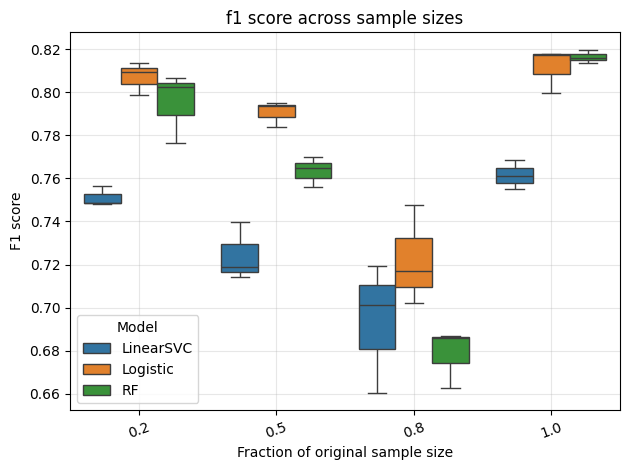

In [ ]:
sns.boxplot(
    data=df,
    x="Sample size",
    y="f1 score",
    hue = "Model"
)
plt.title("f1 score across sample sizes")
plt.xlabel("Fraction of original sample size")
plt.ylabel("F1 score")
plt.tick_params(axis="x", rotation=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
X.shape()
pd.set_option("display.precision", 2)
X.head()
X.tail()
X.info()
X.describe()



In [ ]:
#Minimum disruption
results_disruption = {
    "Sample size": [],
    "Model": [],
    "Seed": [],
    "Best parameters": [],
    "f1 score": []
}


rf = RandomForestClassifier()
rf.fit(X, labels)
importance = rf.feature_importances_
indices = np.argsort(importance)[-10:]
X_new = X.copy()
X_new[:, indices] = 0

for sample_size in sample_sizes:
    for i, n in enumerate(random_seeds):
        print(f"run {i}, sample size {sample_size}")
        results_disruption = training(n, results_disruption, possible_values, X_new, labels, sample_size)   

df_disruption = pd.DataFrame(data=results_disruption)

sns.boxplot(
    data=df,
    x="Sample size",
    y="f1 score",
    hue = "Model"
)
plt.title("f1 score across sample sizes")
plt.xlabel("Fraction of original sample size")
plt.ylabel("F1 score")
plt.tick_params(axis="x", rotation=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Find mislabeling: 
random_seed = 42
#Best model was logistic with 89 components and c=0.1
best_components = 89
best_c = 0.1

mislabled = {
    "index": [],
    "label (mislabeled)": [],
    "predicted label": []
}
def find_mislabeled(random_seed, X, y, best_n, best_c):

    mislabeled = []

    pipe_logistic = Pipeline([
        ('scaler', StandardScaler()),   
        ('pca', PCA(best_n)),
        ('Classifier', LogisticRegression(max_iter=10000, random_state=random_seed, c=best_c))
    ])

    kfold = KFold(n_splits = 5, shufflue = True, random_state= random_seed)

    wrong = np.zeros(len(x))

    for train_idx, val_idx in kfold.split(X,y):
        pipe_logistic.fit(X[train_idx], y[train_idx])
        prediction = pipe_logistic.predict(X[val_idx])

        wrong[val_idx] += (prediction != y[val_idx])

    
    for i in range(len(wrong), 0, -1):
        if wrong[i] >= 3:
            X.pop(i)
            mislabeled.append(i)
    

    return X, mislabeled

X_without, mislabled_data = find_mislabeled(n, X, labels, best_components, best_c)   

df = pd.DataFrame(data=results)
